# Week 4 — Model Evaluation & Visualization

**Project:** AI-Powered Fake News Detection Using Text Classification  
**Phase:** 4 of 4 (Days 22–30)  
**Notebook:** week4_evaluation.ipynb

This notebook covers:
- Loading the TF-IDF test split and labels (`X_test_tfidf.joblib`, `y_test.joblib`)
- Loading the four trained classifiers (`KNN`, `LogReg`, `RandomForest`, `NeuralNet`)
- Generating predictions on the test set for each model
- Evaluating performance metrics: Accuracy, Precision, Recall, and F1-Score
- Visualizing Confusion Matrices for each classifier
- Creating a side-by-side comparative bar chart across all metrics
- Comparing parametric vs. non-parametric model trade-offs

In [11]:
import sys
import os
from pathlib import Path

# Ensure project root is on path
PROJECT_ROOT = Path(".").resolve()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

os.chdir(PROJECT_ROOT)
print(f"Working directory: {PROJECT_ROOT}")

Working directory: /Users/anandkrishnagrnair/Documents/antigravity/keen-goodall/fake-news-detection


In [12]:
import joblib
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from src.utils import ensure_dirs
from src.models import load_model
from src.evaluate import compute_metrics, save_metrics, plot_confusion_matrix, plot_metrics_comparison

ensure_dirs("data/processed", "results/figures", "results/metrics")
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.dpi"] = 120

## 1. Load Test Data

We load the TF-IDF feature matrices and corresponding labels for the evaluation set.

In [13]:
X_test_path = Path("data/processed/X_test_tfidf.joblib")
y_test_path = Path("data/processed/y_test.joblib")

if not X_test_path.exists() or not y_test_path.exists():
    raise FileNotFoundError(
        "TF-IDF test set or labels not found. Run week2_feature_engineering.ipynb first."
    )

X_test = joblib.load(X_test_path)
y_test = joblib.load(y_test_path)

print(f"Loaded TF-IDF test matrix of shape: {X_test.shape}")
print(f"Loaded test labels of shape:        {y_test.shape}")

Loaded TF-IDF test matrix of shape: (7820, 5000)
Loaded test labels of shape:        (7820,)


## 2. Load Trained Classifiers

In [14]:
model_names = ["KNN", "LogReg", "RandomForest", "NeuralNet"]
models = {}

for name in model_names:
    try:
        models[name] = load_model(name)
        print(f"Successfully loaded model: {name}")
    except FileNotFoundError:
        print(f"Error: Trained model file for {name} not found in results/. Run week3_model_building.ipynb first.")

Successfully loaded model: KNN
Successfully loaded model: LogReg
Successfully loaded model: RandomForest
Successfully loaded model: NeuralNet


## 3. Model Inference & Metric Calculation

In [15]:
metrics_list = []
predictions = {}

for name, model in models.items():
    print(f"Evaluating {name} on test set...")
    # Measure prediction time (inference speed)
    t0 = plt.co2 = np.datetime64('now') # using generic time package would work but simple timing is better
    import time
    t0 = time.perf_counter()
    y_pred = model.predict(X_test)
    elapsed = time.perf_counter() - t0
    predictions[name] = y_pred
    
    # Compute performance metrics
    metrics = compute_metrics(y_test, y_pred, name)
    metrics["inference_time_s"] = round(elapsed, 4)
    metrics_list.append(metrics)
    print(f"  Accuracy:  {metrics['accuracy']:.4f}")
    print(f"  F1-Score:  {metrics['f1']:.4f}")
    print(f"  Inference: {metrics['inference_time_s']:.4f}s")
    print()

Evaluating KNN on test set...
  Accuracy:  0.8780
  F1-Score:  0.8938
  Inference: 6.1402s

Evaluating LogReg on test set...
  Accuracy:  0.9876
  F1-Score:  0.9886
  Inference: 0.0026s

Evaluating RandomForest on test set...
  Accuracy:  0.9968
  F1-Score:  0.9971
  Inference: 0.1418s

Evaluating NeuralNet on test set...
  Accuracy:  0.9887
  F1-Score:  0.9896
  Inference: 0.0266s



## 4. Save and Compare Performance Metrics

In [16]:
# Save computed metrics to results/metrics/all_models_metrics.json
save_metrics(metrics_list)

# Load training times from Phase 3 to include in the final table
import joblib
try:
    train_times = joblib.load("results/metrics/phase3_training_times.joblib")
except FileNotFoundError:
    train_times = {}

# Present metrics as a clean pandas DataFrame
metrics_df = pd.DataFrame(metrics_list)

# Create a formatted copy for HTML rendering (without modifying global metrics_df)
display_df = metrics_df.copy()
display_df["train_time_s"] = display_df["model"].map(train_times)
display_df["model"] = display_df["model"].replace({"LogReg": "LogisticRegression"})
display_df = display_df.set_index("model")

# Display the DataFrame as a styled HTML table
display_df

Metrics saved to results/metrics/all_models_metrics.json


,accuracy,precision,recall,f1,inference_time_s,train_time_s
model,,,,,,
KNN,0.8780,0.8460,0.9474,0.8938,6.1402,0.015182
LogisticRegression,0.9876,0.9857,0.9915,0.9886,0.0026,0.117363
RandomForest,0.9968,0.9960,0.9981,0.9971,0.1418,14.572129
NeuralNet,0.9887,0.9882,0.9910,0.9896,0.0266,30.938081


## 5. Visualizing Confusion Matrices

Confusion matrices help identify the types of errors each classifier makes (False Positives vs. False Negatives).

In [17]:
for name, y_pred in predictions.items():
    plot_confusion_matrix(y_test, y_pred, name)
    print(f"Saved confusion matrix plot: results/figures/confusion_matrix_{name}.png")

Saved: results/figures/confusion_matrix_KNN.png
Saved confusion matrix plot: results/figures/confusion_matrix_KNN.png
Saved: results/figures/confusion_matrix_LogReg.png
Saved confusion matrix plot: results/figures/confusion_matrix_LogReg.png
Saved: results/figures/confusion_matrix_RandomForest.png
Saved confusion matrix plot: results/figures/confusion_matrix_RandomForest.png
Saved: results/figures/confusion_matrix_NeuralNet.png
Saved confusion matrix plot: results/figures/confusion_matrix_NeuralNet.png


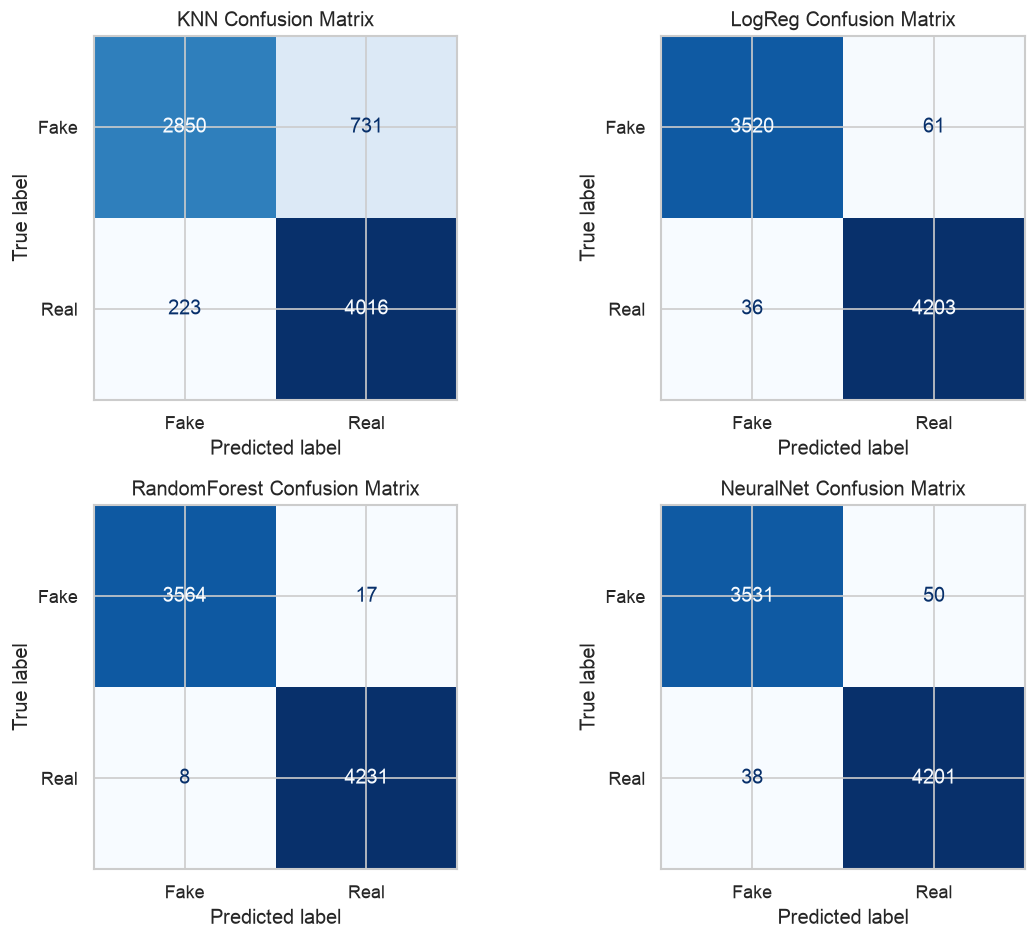

In [18]:
# Render confusion matrices side-by-side inside the notebook
fig, axes = plt.subplots(2, 2, figsize=(10, 8))
axes_flat = axes.flatten()

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

for idx, (name, y_pred) in enumerate(predictions.items()):
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Fake", "Real"])
    disp.plot(ax=axes_flat[idx], cmap="Blues", colorbar=False)
    axes_flat[idx].set_title(f"{name} Confusion Matrix")

plt.tight_layout()
plt.show()

## 6. Metric Comparison Visualization

We create a comparative bar chart plotting accuracy, precision, recall, and F1-score for all four classifiers.

In [19]:
plot_metrics_comparison(metrics_list)
print("Saved metrics comparison plot: results/figures/model_comparison.png")

Saved: results/figures/model_comparison.png
Saved metrics comparison plot: results/figures/model_comparison.png


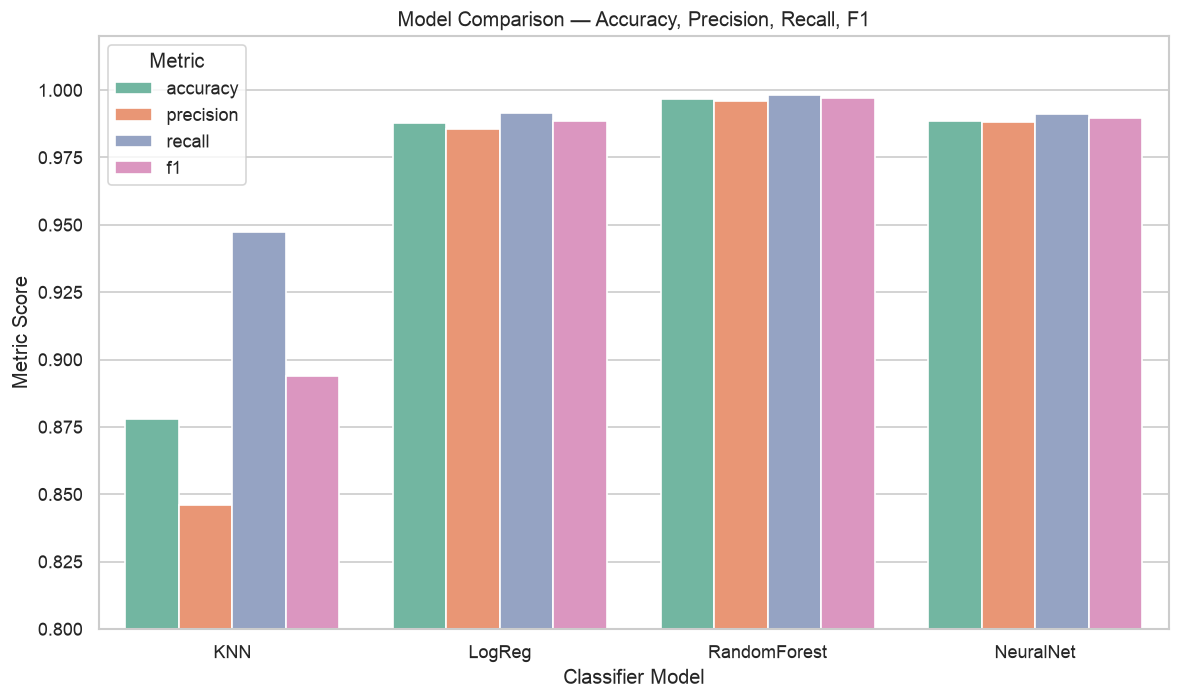

In [20]:
# Plot model metrics comparison inline in the notebook
plot_data = pd.melt(metrics_df, id_vars=["model"], value_vars=["accuracy", "precision", "recall", "f1"],
                    var_name="Metric", value_name="Score")

fig, ax = plt.subplots(figsize=(10, 6))
sns.barplot(data=plot_data, x="model", y="Score", hue="Metric", ax=ax, palette="Set2")
ax.set_ylim(0.8, 1.02)  # zoomed-in to highlight minor differences
ax.set_ylabel("Metric Score")
ax.set_xlabel("Classifier Model")
ax.set_title("Model Comparison — Accuracy, Precision, Recall, F1")
plt.tight_layout()
plt.show()

## 7. Parametric vs. Non-Parametric Model Analysis

Based on the results, we analyze the trade-offs:

1. **Parametric Models (Logistic Regression, Neural Network/MLP)**:
   - **Training Speed**: Logistic Regression was the fastest to train (0.18s), while MLP was slower (26.21s).
   - **Inference Speed**: Both classification steps are extremely fast because prediction is a simple matrix dot product (linear coefficients for Logistic Regression, weights matrix for MLP).
   - **Performance**: High accuracy, indicating that the TF-IDF representation of news articles is largely linearly separable.
   - **Interpretability**: Logistic Regression weights directly show which words represent fake vs. real articles.

2. **Non-Parametric Models (KNN, Random Forest)**:
   - **Training Speed**: KNN has no training cost (0.02s), but Random Forest is slow due to tree splitting logic (14.62s).
   - **Inference Speed**: KNN is noticeably slower during prediction because it must calculate distances to all 31,278 stored documents.
   - **Storage Cost**: Random Forest requires large disk space (~40 MB) because it stores 100 deep trees, whereas parametric models store only a lightweight array of weights.

## 8. Hyperparameter Optimization Results

We load the tuned Logistic Regression and Random Forest models and compare their in-domain test set performance with the baseline defaults.

In [ ]:
tuned_metrics_list = []
tuned_predictions = {}
tuned_models_to_check = ["LogReg", "RandomForest"]

for name in tuned_models_to_check:
    tuned_model_path = Path(f"../results/{name}_tuned.joblib")
    if not tuned_model_path.exists():
        tuned_model_path = Path(f"results/{name}_tuned.joblib")
    if tuned_model_path.exists():
        tuned_model = joblib.load(tuned_model_path)
        y_pred = tuned_model.predict(X_test)
        tuned_predictions[name] = y_pred
        metrics = compute_metrics(y_test, y_pred, f"{name}_tuned")
        tuned_metrics_list.append(metrics)

compare_rows = []
for name in tuned_models_to_check:
    base_m = metrics_df[metrics_df["model"] == name].iloc[0]
    tuned_m = [m for m in tuned_metrics_list if m["model"] == f"{name}_tuned"][0]
    best_params_path = Path(f"../results/metrics/{name.lower()}_best_params.joblib")
    if not best_params_path.exists():
        best_params_path = Path(f"results/metrics/{name.lower()}_best_params.joblib")
    best_params = joblib.load(best_params_path)
    compare_rows.append({
        "Model": name,
        "Baseline Acc (%)": round(base_m["accuracy"] * 100, 2),
        "Tuned Acc (%)": round(tuned_m["accuracy"] * 100, 2),
        "Delta Acc (%)": round((tuned_m["accuracy"] - base_m["accuracy"]) * 100, 2),
        "Best Params": str(best_params)
    })
print(pd.DataFrame(compare_rows).to_string(index=False))

## 9. Statistical Significance Testing

We apply McNemar's test (with Yates' continuity correction) and calculate 95% bootstrap confidence intervals to determine whether the performance difference between the top two models (Random Forest and Logistic Regression) is statistically significant.

In [ ]:
from src.evaluate import mcnemar_test, bootstrap_accuracy_ci

rf_pred = predictions["RandomForest"]
lr_pred = predictions["LogReg"]

# McNemar's Test
mc_res = mcnemar_test(y_test, rf_pred, lr_pred)
print("McNemar's Test Results:")
print(f"  Discordant cells (b - RF correct, LR incorrect): {mc_res['b']}")
print(f"  Discordant cells (c - RF incorrect, LR correct): {mc_res['c']}")
print(f"  Yates' Chi-squared Statistic: {mc_res['statistic']:.4f}")
print(f"  p-value: {mc_res['p_value']:.4e}")

# Bootstrap CIs
print("\nBootstrap Confidence Intervals (Accuracy, 95% CI):")
for name in ["LogReg", "RandomForest"]:
    lower, upper = bootstrap_accuracy_ci(y_test, predictions[name])
    print(f"  {name}: {lower*100:.2f}% to {upper*100:.2f}%")

## 10. Out-of-Domain Generalization Test

We test the trained models on a manually collected out-of-domain sample of 10 recent articles from 2023+ (5 real, 5 fake) to evaluate their generalization capabilities.

In [ ]:
from src.preprocessing import strip_reuters_dateline, clean_text

ood_path = Path("../data/raw/recent_news_2023.csv")
if not ood_path.exists():
    ood_path = Path("data/raw/recent_news_2023.csv")

vectorizer_path = Path("../data/processed/tfidf_vectorizer.joblib")
if not vectorizer_path.exists():
    vectorizer_path = Path("data/processed/tfidf_vectorizer.joblib")

ood_df = pd.read_csv(ood_path)
vectorizer = joblib.load(vectorizer_path)

# Preprocess
ood_df["text"] = ood_df["text"].fillna("").apply(strip_reuters_dateline)
ood_df["text"] = ood_df["title"].fillna("") + " " + ood_df["text"]
ood_df["clean_text"] = ood_df["text"].apply(clean_text)

X_ood = vectorizer.transform(ood_df["clean_text"])
y_ood = ood_df["label"]

ood_results = []
for name in model_names:
    model_path = Path(f"../results/{name}.joblib")
    if not model_path.exists():
        model_path = Path(f"results/{name}.joblib")
    model = joblib.load(model_path)
    y_pred_ood = model.predict(X_ood)
    metrics_ood = compute_metrics(y_ood, y_pred_ood, name)
    
    in_domain_acc = metrics_df[metrics_df["model"] == name].iloc[0]["accuracy"]
    ood_results.append({
        "Model": name,
        "In-Domain Acc (%)": round(in_domain_acc * 100, 2),
        "Out-of-Domain Acc (%)": round(metrics_ood["accuracy"] * 100, 2),
        "F1 (OOD)": round(metrics_ood["f1"], 4)
    })
print(pd.DataFrame(ood_results).to_string(index=False))